In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
import os
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
with zipfile.ZipFile("/content/archive (22).zip", mode='r') as archive:
  archive.extractall()

In [ ]:
train = ImageDataGenerator(rescale=1/255)
test = ImageDataGenerator(rescale=1/255)

train_dataset = train.flow_from_directory("/content/forest_fire/Training and Validation",
                                          target_size=(150,150),
                                          batch_size = 32,
                                          class_mode = 'binary')

test_dataset = test.flow_from_directory("/content/forest_fire/Testing",
                                          target_size=(150,150),
                                          batch_size =32,
                                          class_mode = 'binary')

Found 1832 images belonging to 2 classes.
Found 68 images belonging to 2 classes.


In [ ]:
test_dataset.class_indices

{'fire': 0, 'nofire': 1}

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
model.add(keras.layers.MaxPool2D(2,2))
model.add(keras.layers.Conv2D(64,(3,3),activation='relu'))
model.add(keras.layers.MaxPool2D(2,2))
model.add(keras.layers.Conv2D(128,(3,3),activation='relu'))
model.add(keras.layers.MaxPool2D(2,2))
model.add(keras.layers.Conv2D(128,(3,3),activation='relu'))
model.add(keras.layers.MaxPool2D(2,2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(512,activation='relu'))
model.add(keras.layers.Dense(1,activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
r = model.fit(train_dataset,
         epochs = 5,
         validation_data = test_dataset)

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.7836 - loss: 0.4514 - val_accuracy: 0.8676 - val_loss: 0.3029
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.9470 - loss: 0.1528 - val_accuracy: 0.8529 - val_loss: 0.2650
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.9590 - loss: 0.1547 - val_accuracy: 0.8971 - val_loss: 0.2433
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9346 - loss: 0.1969 - val_accuracy: 0.8824 - val_loss: 0.2593
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9666 - loss: 0.1069 - val_accuracy: 0.9118 - val_loss: 0.1886


In [ ]:
predictions = model.predict(test_dataset)
predictions = np.round(predictions)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step


In [ ]:
predictions

array([[1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.]], dtype=float32)

In [ ]:
print(len(predictions))

68


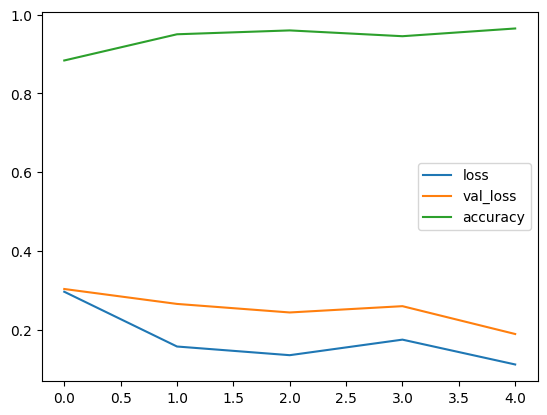

In [ ]:
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.plot(r.history['accuracy'], label='accuracy')
plt.legend()

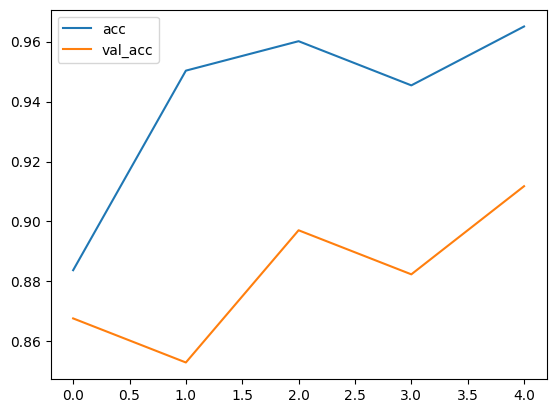

In [ ]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [ ]:
def predictImage(filename):
    img1 = image.load_img(filename,target_size=(150,150))
    plt.imshow(img1)
    Y = image.img_to_array(img1)
    X = np.expand_dims(Y,axis=0)
    val = model.predict(X)
    print(val)
    if val == 1:
        plt.xlabel("No Fire",fontsize=30)
    elif val == 0:
        plt.xlabel("Fire",fontsize=30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
[[1.3519583e-33]]


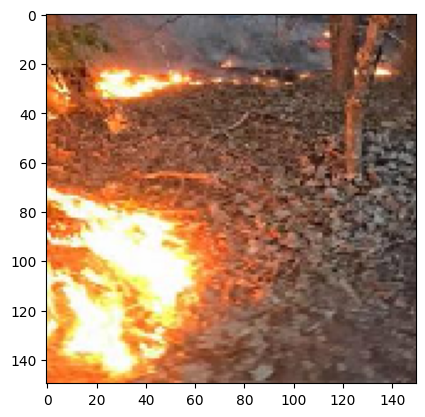

In [ ]:
predictImage("/content/forest_fire/Testing/fire/abc169.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[1.]]


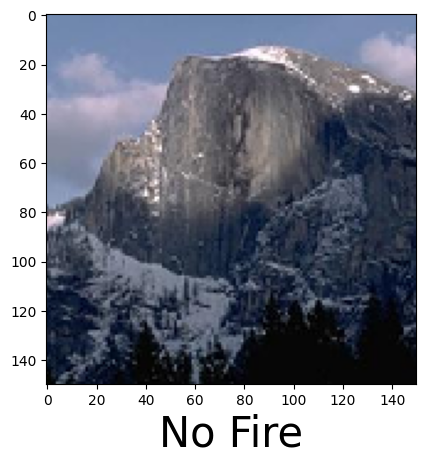

In [ ]:
predictImage('/content/forest_fire/Testing/nofire/abc335.jpg')

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import cv2
import matplotlib.pyplot as plt

# Define the path to the dataset
data_dir = '/content/forest_fire/Training and Validation'  # Replace with the path to your dataset

# Image data generator with a validation split
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2,  # 20% for validation, 80% for training
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Load training and validation data from the same directory using the split
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'  # Use the 'training' subset
)

validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # Use the 'validation' subset
)

# Define the model architecture
def create_model(input_shape=(150, 150, 3)):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create and compile the model
model = create_model()

# Train the model
epochs = 10
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)


Found 1467 images belonging to 2 classes.
Found 365 images belonging to 2 classes.
Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 323ms/step - accuracy: 0.8032 - loss: 0.3838 - val_accuracy: 0.9034 - val_loss: 0.2646
Epoch 2/10
 1/45 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9375 - loss: 0.1616

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9375 - loss: 0.1616 - val_accuracy: 0.8462 - val_loss: 0.1953
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 248ms/step - accuracy: 0.9407 - loss: 0.1780 - val_accuracy: 0.9006 - val_loss: 0.2462
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9688 - loss: 0.1259 - val_accuracy: 0.7692 - val_loss: 0.4180
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 216ms/step - accuracy: 0.9317 - loss: 0.1998 - val_accuracy: 0.9034 - val_loss: 0.2585
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9062 - loss: 0.1295 - val_accuracy: 1.0000 - val_loss: 0.0499
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - accuracy: 0.9665 - loss: 0.1327 - val_accuracy: 0.9205 - val_loss: 0.2121
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0593 - val_accuracy: 1.0000 - val_loss: 0.0964
Epoch 9/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 246ms/step - accuracy: 0.9694 - loss: 0.1189 - val_accuracy: 0.9176 - val_los

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


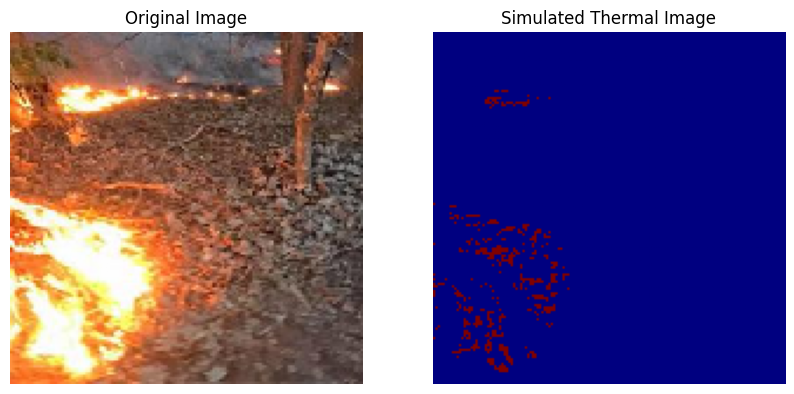

Fire detected!


In [ ]:
# Function to simulate a thermal effect from a visible-spectrum image
def simulate_thermal_effect(img_array):
    # Convert to grayscale to focus on intensity differences
    gray_img = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

    # Apply histogram equalization to improve contrast
    enhanced_gray = cv2.equalizeHist(gray_img)

    # Normalize the intensity to stretch the bright areas
    normalized_img = cv2.normalize(enhanced_gray, None, 0, 255, cv2.NORM_MINMAX)

    # Apply a color map to simulate thermal imaging
    thermal_img = cv2.applyColorMap(normalized_img, cv2.COLORMAP_JET)
    thermal_img = cv2.cvtColor(thermal_img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for consistency
    return thermal_img / 255.0  # Normalize to [0, 1]


# Load a test image and preprocess
test_image_path = '/content/forest_fire/Testing/fire/abc169.jpg'  # Replace with your actual test image path
img = load_img(test_image_path, target_size=(150, 150))
img_array = img_to_array(img) / 255.0  # Normalize to [0, 1]

# Generate the thermal effect image
thermal_image = simulate_thermal_effect(img_array.astype('uint8'))

# Reshape for model prediction
thermal_image_input = np.expand_dims(thermal_image, axis=0)  # Shape (1, 150, 150, 3)

# Make prediction using the thermal image
prediction = model.predict(thermal_image_input)

# Display original and thermal images for comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(thermal_image)
plt.title("Simulated Thermal Image")
plt.axis('off')
plt.show()

# Interpret prediction
if prediction[0] > 0.48:  # Assuming binary classification with fire as class 1
    print("Fire detected!")
else:
    print("No fire detected.")

In [ ]:
model.save("fire_detection_model.h5")

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
import matplotlib.pyplot as plt
import cv2


In [ ]:
def create_model(input_shape=(224, 224, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', name='conv1')(inputs)
    x = tf.keras.layers.MaxPooling2D((2, 2), name='pool1')(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', name='conv2')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2), name='pool2')(x)
    x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', name='conv3')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2), name='pool3')(x)
    x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', name='conv4')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2), name='pool4')(x)
    x = tf.keras.layers.Flatten(name='flatten')(x)
    x = tf.keras.layers.Dense(64, activation='relu', name='dense1')(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
model = create_model()
last_conv_layer_name = "conv4"  # Fixed layer name for Grad-CAM

# Directories for Training and Testing
train_dir = "/content/forest_fire/Training and Validation"
test_dir = "/content/forest_fire/Testing"


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 80% training, 20% validation
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 1467 images belonging to 2 classes.
Found 365 images belonging to 2 classes.


In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    validation_data=val_generator,
    validation_steps=val_generator.samples // 32,
    epochs=15
)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 569ms/step - accuracy: 0.7680 - loss: 0.4554 - val_accuracy: 0.8693 - val_loss: 0.4386
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.8750 - loss: 0.4174 - val_accuracy: 0.7692 - val_loss: 0.5203
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 27s 473ms/step - accuracy: 0.9410 - loss: 0.1666 - val_accuracy: 0.9148 - val_loss: 0.2496
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9688 - loss: 0.0592 - val_accuracy: 1.0000 - val_loss: 0.0463
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 474ms/step - accuracy: 0.9506 - loss: 0.1348 - val_accuracy: 0.8920 - val_loss: 0.3034
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8750 - loss: 0.1719 - val_accuracy: 1.0000 - val_loss: 0.1122
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 484ms/step - accuracy: 0.9542 - loss: 0.1345 - val_accuracy: 0.8892 - val_loss: 0.3581
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9062 - loss: 0.2698 - val_accuracy: 0.92

In [ ]:
model.save("fire_detection_model.h5")

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Lower the detection threshold further to capture weak signals
threshold = 0.05

def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 821ms/step
Prediction confidence: 0.9444413185119629
Fire detected!


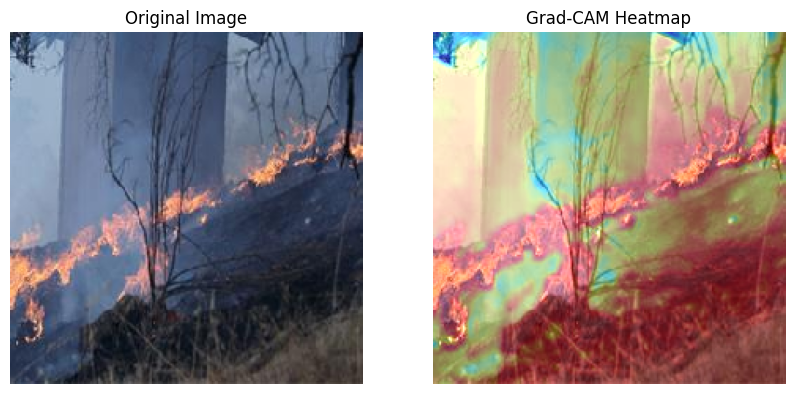

In [ ]:
def process_and_predict(image_path, model, last_conv_layer_name="conv3"):
    # Load and preprocess the image
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict the probability of fire
    prediction = model.predict(img_array)[0][0]
    print(f"Prediction confidence: {prediction}")

    # Decide if fire is detected based on the threshold
    if prediction > threshold:
        print("Fire detected!")
    else:
        print("No fire detected.")

    # Generate the Grad-CAM heatmap
    heatmap = get_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Process and overlay the heatmap onto the original image
    img = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)  # Scale to 255 for color mapping
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose heatmap on the original image
    superimposed_img = np.clip((heatmap * 0.4 / 255) + img, 0, 1)

    # Plot the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(superimposed_img)
    plt.axis("off")

    plt.show()

image_path = "/content/forest_fire/Testing/fire/abc171.jpg"
process_and_predict(image_path, model, last_conv_layer_name="conv2")

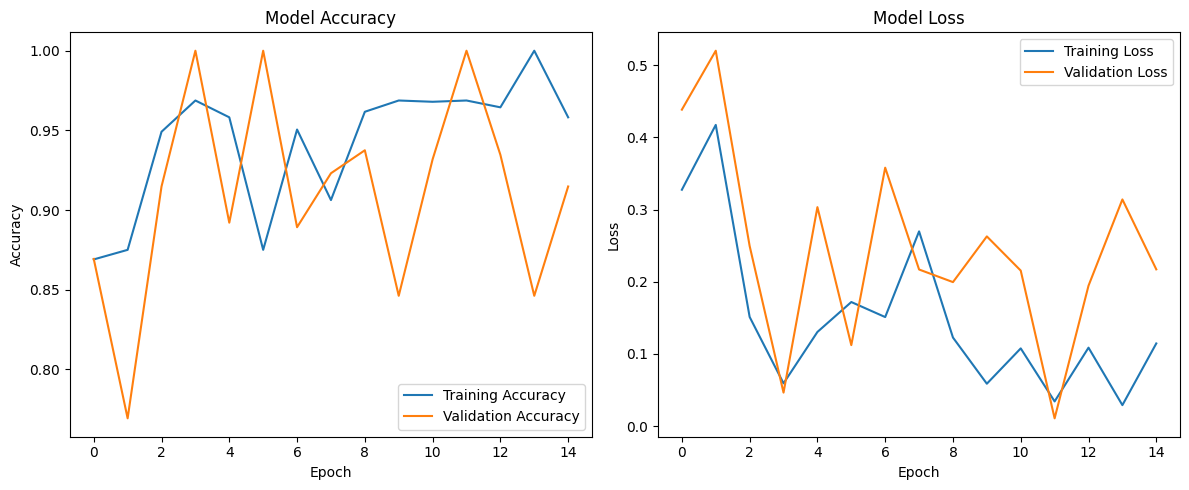

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()
